# 1. Problem Statement
Build and compare Vanilla RNN, LSTM, and GRU models for next-word text generation using a custom paragraph dataset.

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.utils import to_categorical


In [4]:

corpus = '''Artificial Intelligence is transforming industries across the world. Machine learning and deep learning help computers learn patterns from data. Text generation models can predict the next word in a sequence and create meaningful sentences. Recurrent Neural Networks, LSTMs, and GRUs are commonly used sequence models in deep learning.'''


In [5]:

# Text Cleaning
corpus = corpus.lower()


In [6]:

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1


In [7]:

# N-Gram Sequence Creation
input_sequences = []
for line in corpus.split('.'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_seq_len = max(len(x) for x in input_sequences)


In [8]:

# Padding
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')
)


In [9]:

# X and y Creation
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)


In [10]:

# Vanilla RNN Model
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_seq_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='categorical_crossentropy', optimizer='adam')


C:\Users\Dell\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:

# LSTM Model
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_seq_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam')


In [12]:

# GRU Model
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_seq_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='categorical_crossentropy', optimizer='adam')


In [13]:

# Model Summaries
rnn_model.summary()
lstm_model.summary()
gru_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:

# Training (Epochs = 200)
rnn_hist = rnn_model.fit(X, y, epochs=200, verbose=1)
lstm_hist = lstm_model.fit(X, y, epochs=200, verbose=1)
gru_hist = gru_model.fit(X, y, epochs=200, verbose=1)


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 3.7119
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.5612
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.4514
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.3336
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.2158
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.0976
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.9856
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8697
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.7506
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.6394
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5173
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.3981
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.2862
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.1684
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.0474
Epoch 16/200
2/2 ━━

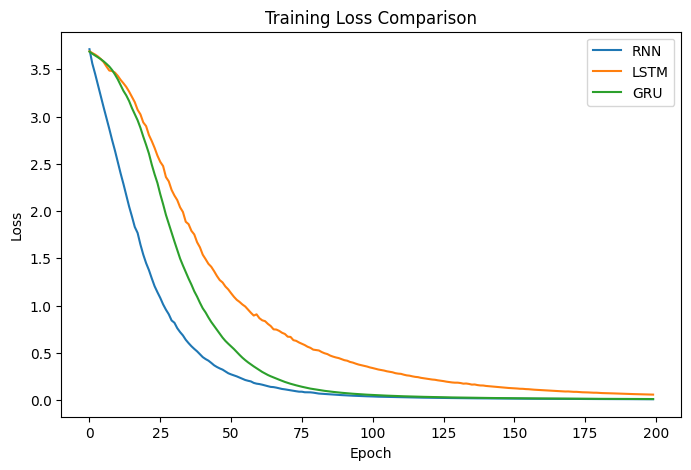

In [15]:

# Training Loss Comparison Graph
plt.figure(figsize=(8,5))
plt.plot(rnn_hist.history['loss'], label='RNN')
plt.plot(lstm_hist.history['loss'], label='LSTM')
plt.plot(gru_hist.history['loss'], label='GRU')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.show()


In [16]:

# generate_text() Function
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += ' ' + output_word
    return seed_text


In [17]:

# RNN Generated Output
print(generate_text(rnn_model, 'artificial intelligence', 10))


artificial intelligence is transforming industries across the world are commonly used sequence


In [18]:

# LSTM Generated Output
print(generate_text(lstm_model, 'artificial intelligence', 10))


artificial intelligence is transforming industries across the world world world a data


In [19]:

# GRU Generated Output
print(generate_text(gru_model, 'artificial intelligence', 10))


artificial intelligence is transforming industries across the world world world in a


In [20]:

# Performance Comparison Table
comparison = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Final Loss':[
        rnn_hist.history['loss'][-1],
        lstm_hist.history['loss'][-1],
        gru_hist.history['loss'][-1]
    ]
})
comparison


,Model,Final Loss
0,RNN,0.008557
1,LSTM,0.057335
2,GRU,0.010344



# 20. Conclusion

- Custom paragraph corpus used.
- Embedding Dimension = 128.
- Hidden Units = 128.
- Epochs = 200.
- Generated 10 words.
- Compared Vanilla RNN, LSTM, and GRU performance.
